In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/splits.csv")
df.head()

,filepath,filename,label,split
0,data/raw/Garbage classification/Garbage classi...,cardboard10.jpg,cardboard,test
1,data/raw/Garbage classification/Garbage classi...,cardboard102.jpg,cardboard,test
2,data/raw/Garbage classification/Garbage classi...,cardboard110.jpg,cardboard,test
3,data/raw/Garbage classification/Garbage classi...,cardboard111.jpg,cardboard,test
4,data/raw/Garbage classification/Garbage classi...,cardboard117.jpg,cardboard,test


In [2]:
df["label"].value_counts().sort_index()

label
cardboard    403
glass        501
metal        410
paper        594
plastic      482
trash        137
Name: count, dtype: int64

In [3]:
df["split"].value_counts()

split
train    1768
test      380
val       379
Name: count, dtype: int64

In [4]:
pd.crosstab(df["label"], df["split"])

split,test,train,val
label,,,
cardboard,60,282,61
glass,76,350,75
metal,62,287,61
paper,89,416,89
plastic,73,337,72
trash,20,96,21


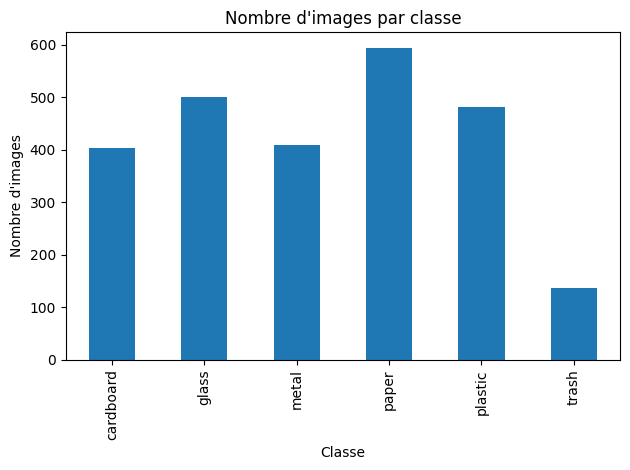

In [5]:
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Nombre d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

manifest = pd.read_parquet("../data/processed/manifest.parquet")
manifest.head()

,filepath,filename,label,split,width,height,mode,file_size_bytes,read_error
0,data/raw/Garbage classification/Garbage classi...,cardboard10.jpg,cardboard,test,512,384,RGB,21683,None
1,data/raw/Garbage classification/Garbage classi...,cardboard102.jpg,cardboard,test,512,384,RGB,18015,None
2,data/raw/Garbage classification/Garbage classi...,cardboard110.jpg,cardboard,test,512,384,RGB,17368,None
3,data/raw/Garbage classification/Garbage classi...,cardboard111.jpg,cardboard,test,512,384,RGB,24881,None
4,data/raw/Garbage classification/Garbage classi...,cardboard117.jpg,cardboard,test,512,384,RGB,21221,None


In [7]:
manifest[["width", "height", "file_size_bytes"]].describe()

,width,height,file_size_bytes
count,2527.0,2527.0,2527.000000
mean,512.0,384.0,17127.978631
std,0.0,0.0,7598.745148
min,512.0,384.0,5604.000000
25%,512.0,384.0,11907.500000
50%,512.0,384.0,15385.000000
75%,512.0,384.0,20303.000000
max,512.0,384.0,57868.000000


In [8]:
manifest["read_error"].isna().value_counts()

read_error
True    2527
Name: count, dtype: int64

In [9]:
manifest.groupby("label")[["width", "height"]].median()

,width,height
label,,
cardboard,512.0,384.0
glass,512.0,384.0
metal,512.0,384.0
paper,512.0,384.0
plastic,512.0,384.0
trash,512.0,384.0


In [10]:
manifest["aspect_ratio"] = manifest["width"] / manifest["height"]
manifest[["aspect_ratio"]].describe()

,aspect_ratio
count,2.527000e+03
mean,1.333333e+00
std,2.220886e-16
min,1.333333e+00
25%,1.333333e+00
50%,1.333333e+00
75%,1.333333e+00
max,1.333333e+00


In [11]:
import pandas as pd

hist_base = pd.read_csv("../models/cnn_baseline/history.csv")
hist_impr = pd.read_csv("../models/cnn_improved/history.csv")

hist_base["run"] = "baseline"
hist_impr["run"] = "improved"

hist_base.head(), hist_impr.head()

(   epoch  train_loss  val_loss   val_acc       run
 0      1    1.315832  1.045534  0.649077  baseline
 1      2    0.866728  0.858355  0.712401  baseline
 2      3    0.708487  0.725519  0.754617  baseline
 3      4    0.634114  0.703552  0.757256  baseline
 4      5    0.582435  0.670940  0.749340  baseline,
    epoch  train_loss  val_loss   val_acc       run
 0      1    0.679599  0.991969  0.744063  improved
 1      2    0.357903  0.512522  0.841689  improved
 2      3    0.212440  0.436833  0.860158  improved
 3      4    0.118605  0.327236  0.897098  improved
 4      5    0.070741  0.286183  0.923483  improved)

In [12]:
import matplotlib.pyplot as plt

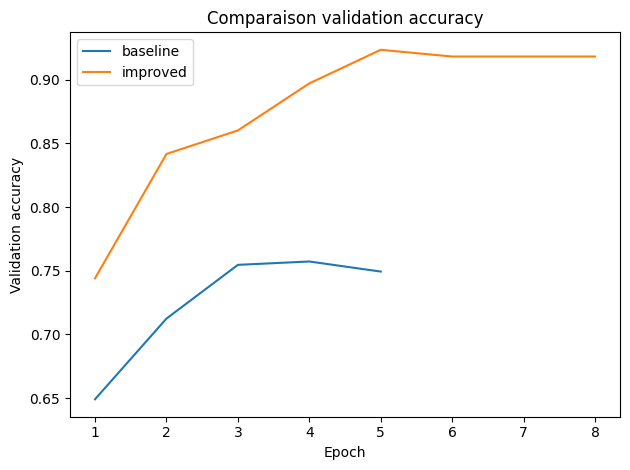

In [13]:
plt.plot(hist_base["epoch"], hist_base["val_acc"], label="baseline")
plt.plot(hist_impr["epoch"], hist_impr["val_acc"], label="improved")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Comparaison validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

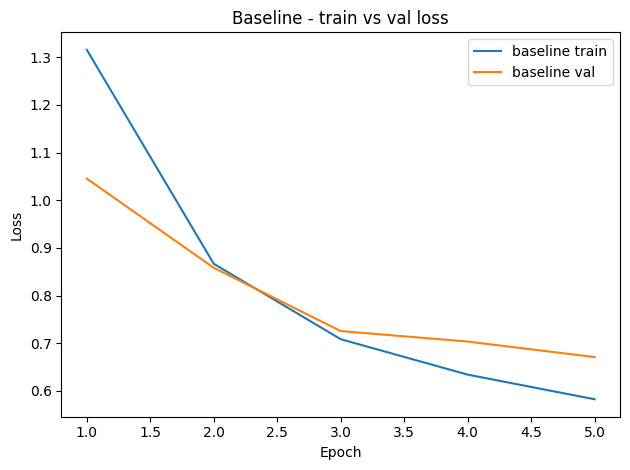

In [14]:
plt.plot(hist_base["epoch"], hist_base["train_loss"], label="baseline train")
plt.plot(hist_base["epoch"], hist_base["val_loss"], label="baseline val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline - train vs val loss")
plt.legend()
plt.tight_layout()
plt.show()

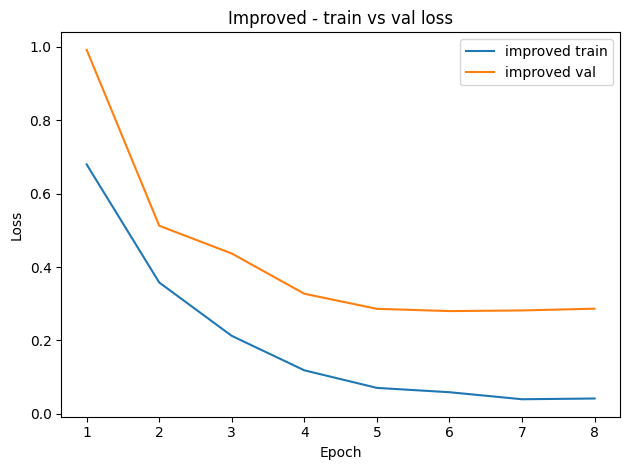

In [15]:
plt.plot(hist_impr["epoch"], hist_impr["train_loss"], label="improved train")
plt.plot(hist_impr["epoch"], hist_impr["val_loss"], label="improved val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved - train vs val loss")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
from pathlib import Path

base_metrics = Path("../models/cnn_baseline/metrics.txt").read_text(encoding="utf-8")
impr_metrics = Path("../models/cnn_improved/metrics.txt").read_text(encoding="utf-8")

print("=== BASELINE ===")
print(base_metrics)
print("\n=== IMPROVED ===")
print(impr_metrics)

=== BASELINE ===
best_epoch: 4
best_val_acc: 0.7573
test_acc: 0.7711
test_loss: 0.6469

classification_report:
              precision    recall  f1-score   support

   cardboard     0.8333    0.9167    0.8730        60
       glass     0.7424    0.6447    0.6901        76
       metal     0.7258    0.7258    0.7258        62
       paper     0.9136    0.8315    0.8706        89
     plastic     0.6630    0.8356    0.7394        73
       trash     0.6923    0.4500    0.5455        20

    accuracy                         0.7711       380
   macro avg     0.7617    0.7340    0.7407       380
weighted avg     0.7763    0.7711    0.7689       380


confusion_matrix:
[[55  0  1  4  0  0]
 [ 2 49  6  0 19  0]
 [ 2  8 45  0  6  1]
 [ 6  1  3 74  3  2]
 [ 0  6  4  1 61  1]
 [ 1  2  3  2  3  9]]

=== IMPROVED ===
best_epoch: 5
best_val_acc: 0.9235
test_acc: 0.9079
test_loss: 0.2896

classification_report:
              precision    recall  f1-score   support

   cardboard     0.9818    0.9000